In [7]:
# import cs_optimization_Optuna
import sys
import os
from datetime import datetime
import json
import pickle
import numpy as np
import pandas as pd
import optuna

# プロジェクトのルートディレクトリをパスに追加
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
    
from src.simulation.run_emates import run_parallel_emates_simulations
from src.simulation.data_load import save_data_to_pickle
from src.util.path_manager import get_paths

current_time = datetime.now().strftime('%Y%m%d_%H%M')
SAVE_DIR = current_time
os.makedirs(SAVE_DIR, exist_ok=True)
FAILURE_FLAG = True

        
"""充電ステーションのコスト計算:https://www.notion.so/2098044c3b9180acade1c42c52872eda?source=copy_link"""
def total_costs_yearly(result_file) -> tuple:
    """年間の総コストを計算"""
    with open(result_file, 'rb') as f:
        emates_result = pickle.load(f)
    timeseries_kw = emates_result['time_series_kw']
    cs_config = emates_result['cs_config']
    initial_costs = _calc_initial_costs(cs_config, timeseries_kw)
    running_costs_yearly = _calc_running_costs(cs_config, timeseries_kw)
    total_costs = initial_costs + running_costs_yearly
    return total_costs.sum(), emates_result

def _calc_initial_costs(cs_config, timeseries_kw)-> np.ndarray:
    """初期コストの計算"""
    CHARGER_COST = {"50": 380, "90": 666, "100": 730}
    SUBSTATION_COST_PER_KW = 2
    INSTALLATION_COST = 250
    capacity_list = cs_config['cap_kw']
    ports_list = cs_config['ports']
    ports_array = np.array(ports_list)
    capacity_array = np.array(capacity_list)
    max_capacity = ports_array * capacity_array
    charger_costs = np.array([CHARGER_COST[str(c)] for c in capacity_list])
    cs_costs = charger_costs * ports_array
    substation_costs = (SUBSTATION_COST_PER_KW * max_capacity).reshape(-1)
    installation_costs = np.array([INSTALLATION_COST] * len(ports_list))
    initial_costs = cs_costs + substation_costs + installation_costs
    return initial_costs

def _calc_running_costs(cs_config, timeseries_kw)-> np.ndarray:
    """年間のランニングコストの計算"""
    MAINTENANCE_COST_PER_YEAR = 30
    CONTRACT_COST_PER_KW_MONTH = 1911e-4
    USAGE_COST_PER_KWH_MONTH = 18e-4
    CHARGING_PRICE_PER_KWH = 50e-4
    ports_array = np.array(cs_config['ports'])
    capacity_array = np.array(cs_config['cap_kw'])
    max_capacity = ports_array * capacity_array
    maintainance_costs = np.array([MAINTENANCE_COST_PER_YEAR] * len(ports_array))
    contract_costs = CONTRACT_COST_PER_KW_MONTH * max_capacity.reshape(-1) * 12
    usage_costs = USAGE_COST_PER_KWH_MONTH * timeseries_kw.sum(axis=0) * 12
    charging_revenue = CHARGING_PRICE_PER_KWH * timeseries_kw.sum(axis=0) * 12
    running_costs_yearly = maintainance_costs + contract_costs + usage_costs - charging_revenue
    return running_costs_yearly



def cs_placement_objective(trial) -> float:
    """CS配置最適化の目的関数"""
    # 1.OptunaによるCS配置の提案
    cs_config = _set_cs_placement(trial)
    
            
    # 2. 1で設定したCS配置の妥当性チェック
    if not _check_cs_placement(cs_config):
        print("CS配置が不適切です。最低2箇所の充電ステーションを設置してください。")
        return float('inf')
    
    #3. シミュレーション実行とコスト計算。evaluation_costを最小化したい！
    evaluation_cost, emates_results = simulate_and_calculate_cost(cs_config, trial)
    
    #4.ペナルティがあればここに追加...
    """
    # 最低限満たしてほしい条件：充電実現率80％以上の確保
    # 追記：2025/7/3
    # これは保障として入れていたが，目的関数に総旅行時間を加えることで
    # 実質的に満たされることが期待されることを仮定してコメントアウト
    
    HOPED_CHARGING_RATE = 0.8
    vehicle_trip = emates_results['vehicle_trip']
    charging_loss = emates_results['charging_loss']
    
    num_charging_loss = len(charging_loss)
    num_charging_trip = len(vehicle_trip[vehicle_trip['startChargingTime'] != 0])
    satisfied_charging_rate = (num_charging_trip - num_charging_loss) / num_charging_trip
    if satisfied_charging_rate < HOPED_CHARGING_RATE:
        print(f"充電実現率が低い: {satisfied_charging_rate:.2%}。ペナルティを適用します。")
        # 実現率に応じたペナルティを追加
        evaluation_cost += (HOPED_CHARGING_RATE - satisfied_charging_rate) * 1000
    """
    return evaluation_cost

def _check_cs_placement(cs_config: dict) -> bool:
    installed_locations = [i for i, port in enumerate(cs_config['ports']) if port > 0]
    if len(installed_locations) < 2:  # 最低2箇所は設置
        return False
    
    # ほかに制約があればここに追加
    # ....
    return True
    

def _set_cs_placement(trial)-> dict:
    paths = get_paths(1)  # worker_idは1と仮定
    # csList.txtの情報を取得
    cslist_file = paths['csList']
    with open(cslist_file, 'r') as f:
        cslist_data = f.readlines()
    cslist_data = [line.strip() for line in cslist_data if line.strip()]
    csids = [int(line.split(',')[0]) for line in cslist_data if line.strip()]
    ports_list = [int(line.split(',')[1]) for line in cslist_data if line.strip()]
    cap_kw_list = [int(line.split(',')[2]) for line in cslist_data if line.strip()]
    
    
    cs_config = {
        'csids': [],
        'ports': [],
        'cap_kw': []
    }
    for i, csid in enumerate(csids):
        # trialの最初は元々のデータを使用
        if trial.number == 0:
            ports = ports_list[i]
            capacity = cap_kw_list[i]
        else:        
            # 設置するかどうかを決定
            ports = trial.suggest_int(f'ports_{i}', 0, 4)
            if ports > 0:
                # 設置する場合のみ容量を決定
                capacity = trial.suggest_categorical(f'capacity_{i}', [50, 90, 100])
            else:
                # 設置しない場合は容量は任意（50に固定）
                capacity = 90
        # ✅ 修正：辞書に追加
        
        cs_config['csids'].append(csid)
        cs_config['ports'].append(ports)
        cs_config['cap_kw'].append(capacity)
    return cs_config

def simulate_and_calculate_cost(cs_configs : dict, trial) -> tuple:
    
    """シミュレーション実行とコスト計算（ダミー）"""
    # 0.シミュレーション前準備
    # 故障シナリオcsvファイルの作成
    if FAILURE_FLAG:
        # 設置されているCS数分の故障シナリオを作成
        installed_cs_indices = [i for i, ports in enumerate(cs_configs['ports']) if ports > 0]
        all_costs = []
        all_results = []
        
        for failure_cs_idx in installed_cs_indices:
            # 各CSが故障するシナリオを作成
            _create_failure_info(cs_config=cs_configs, failure_cs_index=failure_cs_idx)
            
            # シミュレーション実行
            run_parallel_emates_simulations(base_config=cs_configs, parallel_count=1)
            
            # データの保存
            results_filename = f"trial_{trial.number}_failure_cs_{failure_cs_idx}.pkl"
            results_filepath = os.path.join(SAVE_DIR, results_filename)
            save_data_to_pickle(worker_id=1, filename=results_filepath)
            
            # 評価コストの計算
            evaluation_cost, emates_results = total_costs_yearly(result_file=results_filepath)
            all_costs.append(evaluation_cost)
            all_results.append(emates_results)
        
        # 最悪ケース（最大コスト）を返す
        worst_case_idx = np.argmax(all_costs)
        return all_costs[worst_case_idx], all_results[worst_case_idx]
    else:
        # 故障なしのシナリオ
        run_parallel_emates_simulations(base_config=cs_configs, parallel_count=1)
        results_filename = f"trial_{trial.number}.pkl"
        results_filepath = os.path.join(SAVE_DIR, results_filename)
        save_data_to_pickle(worker_id=1, filename=results_filepath)
        evaluation_cost, emates_results = total_costs_yearly(result_file=results_filepath)
        return evaluation_cost, emates_results

def _create_failure_info(cs_config: dict, failure_cs_index: int = None) -> None:
    """故障情報の作成"""
    time_interval = 3600  # 1時間ごと
    max_time = 24 * 3600  # 24時間
    failure_time = 3600 * 12 # 12時に故障
    paths = get_paths(1)
    OPENDSS_PATH = f'{paths['result']}/opendss'

    var_names = ["Type","Node", "Csid", "Chgrid", "kW_0min", 
                "kW_60min", "kW_120min", "Yen_0min", "Yen_60min", "Yen_120min"]
    
    for time in range(time_interval, max_time + time_interval, time_interval):
        rows = []
        
        for cs_idx, (csid, ports, cap_kw) in enumerate(zip(cs_config['csids'], cs_config['ports'], cs_config['cap_kw'])):
            if ports == 0:  # 設置されていないCSはスキップ
                continue
                
            for chgrid in range(ports):
                # 故障時間かつ指定されたCSの場合
                if time == failure_time and cs_idx == failure_cs_index:
                    # 故障CSは出力を0に設定
                    row = [
                        "F",         # Type
                        "Any",       # Node
                        csid,        # Csid
                        chgrid,      # Chgrid
                        0,           # kW_0min (故障のため0)
                        -1,          # kW_60min
                        -1,          # kW_120min
                        -1,          # Yen_0min
                        -1,          # Yen_60min
                        -1           # Yen_120min
                    ]
                else:
                    # 通常の出力設定
                    row = [
                        "F",         # Type
                        "Any",       # Node
                        csid,        # Csid
                        chgrid,      # Chgrid
                        cap_kw,      # kW_0min
                        -1,          # kW_60min
                        -1,          # kW_120min
                        -1,          # Yen_0min
                        -1,          # Yen_60min
                        -1           # Yen_120min
                    ]
                rows.append(row)
        
        # CSVファイルに保存
        E_filename = f"E{time+1:06d}"
        df = pd.DataFrame(rows, columns=var_names)
        save_Efile_path = f"{OPENDSS_PATH}/{E_filename}.csv"
        df.to_csv(save_Efile_path, index=False)


# 最適化実行
def run_optuna(n_trials = 1, reults_dir = 'optuna_results'):
    """Optunaによる最適化実行"""
    # SQLiteデータベースを使用したStudy管理
    db_path = os.path.join(SAVE_DIR, 'optuna_study.db')
    db_url = f"sqlite:///{db_path}"
    study_name = "cs_optimization"
    
    # 既存のSQLiteデータベースからStudyを読み込み
    try:
        study = optuna.load_study(study_name=study_name, storage=db_url)
        print(f"既存のSQLiteStudyを読み込みました（トライアル数: {len(study.trials)}）")
        print(f"現在の最適値: {study.best_value}")
        print(f"現在の最適パラメータ: {study.best_params}")
    except KeyError:
        # 新しいStudyを作成
        study = optuna.create_study(
            direction='minimize', 
            study_name=study_name, 
            storage=db_url
        )
        print("新しいSQLiteStudyを作成しました")
        
    # 最適化実行（継続）
    study.optimize(cs_placement_objective, n_trials=n_trials)
    # 最適化結果の保存
    save_optuna_results(study)


# Optuna実行後のデータ保存
def save_optuna_results(study)-> None:
    """最適化結果を保存する関数"""

    print(f"追加で{n_trials}トライアルを実行します...")
    


    print(f"最適化完了！")
    print(f"最適コスト: {study.best_value}")
    print(f"最適配置: {study.best_params}")
    print(f"総トライアル数: {len(study.trials)}")

    # 最適化結果の保存
    optimization_results = {
        'best_value': study.best_value,
        'best_params': study.best_params,
        'n_trials': len(study.trials),
        'optimization_time': datetime.now().strftime('%Y%m%d_%H:%M:%S')
    }

    # 各試行の結果を保存
    trials_data = []
    for trial in study.trials:
        trial_info = {
            'number': trial.number,
            'value': trial.value,
            'params': trial.params,
            'state': trial.state.name
        }
        trials_data.append(trial_info)

    optimization_results['trials'] = trials_data

    # JSONファイルとして保存
    results_dir = 'optimization_results'
    results_dir = os.path.join(SAVE_DIR, results_dir)
    os.makedirs(results_dir, exist_ok=True)

    with open(os.path.join(results_dir, 'optuna_results.json'), 'w', encoding='utf-8') as f:
        json.dump(optimization_results, f, indent=2, ensure_ascii=False)

    # Studyオブジェクトを両方の形式で保存（互換性のため）
    study_filename = os.path.join(results_dir, 'optuna_study.pkl')
    with open(study_filename, 'wb') as f:
        pickle.dump(study, f)

    print(f"最適化結果を {results_dir}/optuna_results.json に保存しました")
    print(f"学習済みStudyオブジェクトを {study_filename} に保存しました")
    print(f"SQLiteデータベースにも自動保存されました: {db_path}")

# run_optuna(n_trials=1)


### 最適化推移の可視化

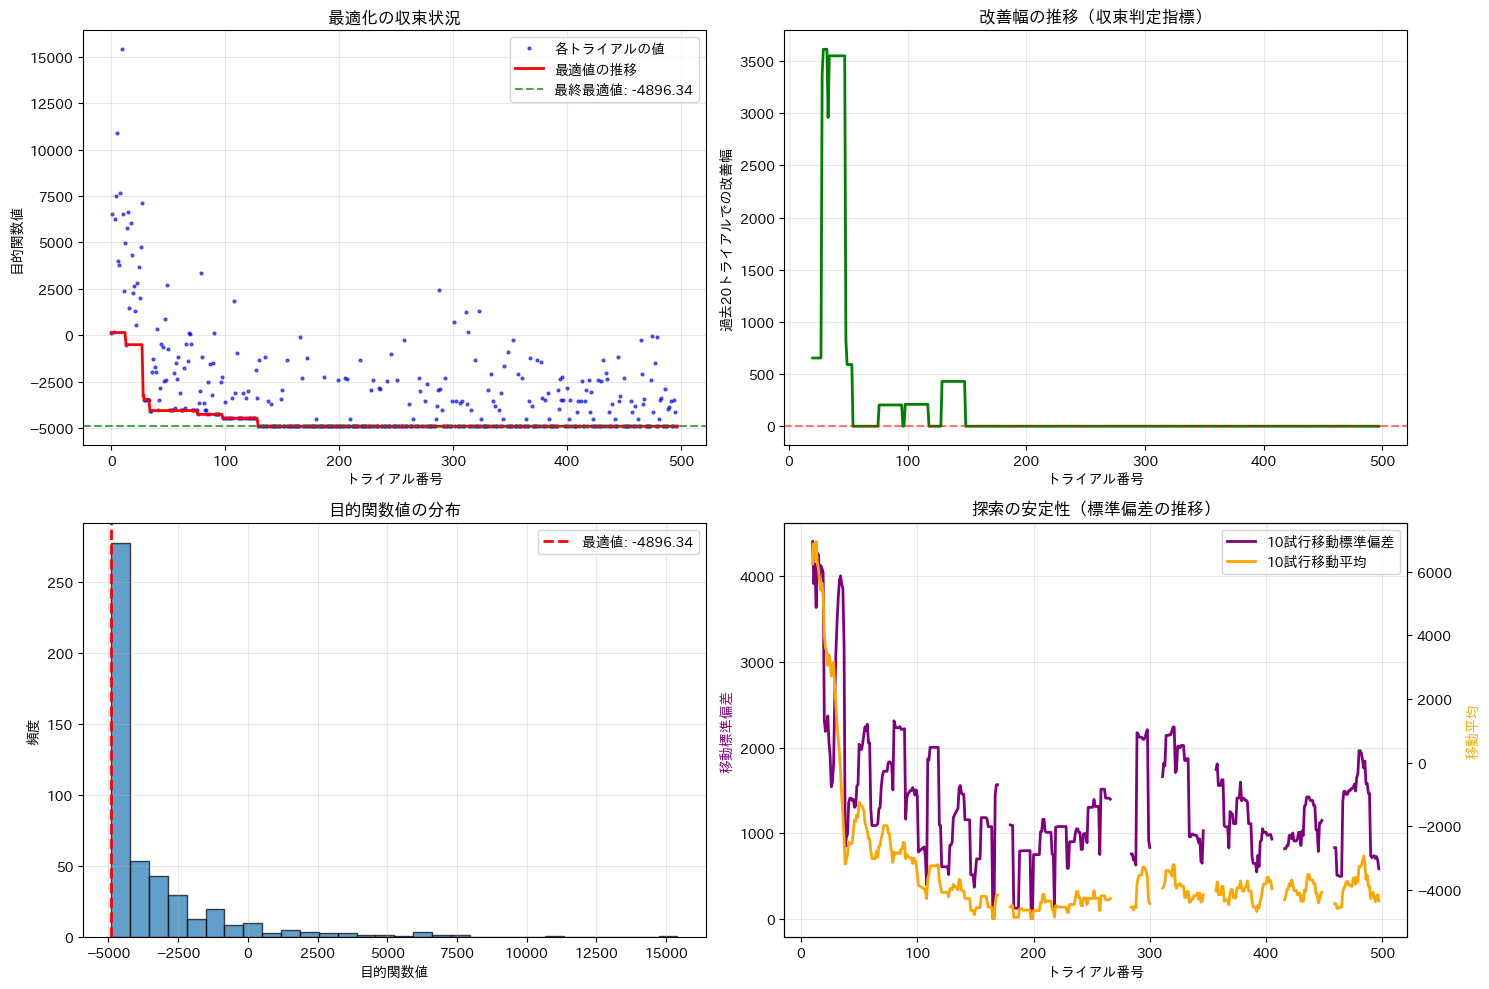

=== 最適化収束性の評価 ===
総トライアル数: 498
最終最適値: -4896.34
最適値に初回到達: トライアル 129 (25.9%時点)
過去30トライアルで最適値更新: なし（収束済み）
後半での改善幅: 0.00
判定: 収束済み ✓

最適パラメータ:
  ports_0: 3
  capacity_0: 100
  ports_1: 0
  ports_2: 0
  ports_3: 0
  ports_4: 0
  ports_5: 1
  capacity_5: 50
  ports_6: 0
  ports_7: 0


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import japanize_matplotlib
import warnings
warnings.filterwarnings("ignore")

# JSONファイルを読み込み
with open('../20250703_2245/optimization_results/optuna_results.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# データの準備
trials = data['trials']
trial_numbers = [trial['number'] for trial in trials]
values = [trial['value'] for trial in trials]
best_values = np.minimum.accumulate(values)  # 累積最小値（最適値の推移）

# 図1: 基本的な収束グラフ
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# 1. 各トライアルの目的関数値と最適値の推移
ax1.plot(trial_numbers, values, 'b.', alpha=0.6, markersize=4, label='各トライアルの値')
ax1.plot(trial_numbers, best_values, 'r-', linewidth=2, label='最適値の推移')
ax1.axhline(y=data['best_value'], color='g', linestyle='--', alpha=0.7, label=f'最終最適値: {data["best_value"]:.2f}')
ax1.set_xlabel('トライアル番号')
ax1.set_ylabel('目的関数値')
ax1.set_title('最適化の収束状況')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. 最近50トライアルでの改善幅
improvement_window = 20
recent_improvements = []
for i in range(improvement_window, len(best_values)):
    improvement = best_values[i-improvement_window] - best_values[i]
    recent_improvements.append(improvement)

ax2.plot(range(improvement_window, len(best_values)), recent_improvements, 'g-', linewidth=2)
ax2.set_xlabel('トライアル番号')
ax2.set_ylabel(f'過去{improvement_window}トライアルでの改善幅')
ax2.set_title('改善幅の推移（収束判定指標）')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 3. 値の分布（ヒストグラム）
finite_value = [v for v in values if v != float('inf')]
ax3.hist(finite_value, bins=30, alpha=0.7, edgecolor='black')
ax3.axvline(x=data['best_value'], color='r', linestyle='--', linewidth=2, label=f'最適値: {data["best_value"]:.2f}')
ax3.set_xlabel('目的関数値')
ax3.set_ylabel('頻度')
ax3.set_title('目的関数値の分布')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. 収束性の統計指標
window_size = 10
rolling_std = []
rolling_mean = []

for i in range(window_size, len(values)):
    window_values = values[i-window_size:i]
    rolling_std.append(np.std(window_values))
    rolling_mean.append(np.mean(window_values))

ax4.plot(range(window_size, len(values)), rolling_std, 'purple', linewidth=2, label=f'{window_size}試行移動標準偏差')
ax4_twin = ax4.twinx()
ax4_twin.plot(range(window_size, len(values)), rolling_mean, 'orange', linewidth=2, label=f'{window_size}試行移動平均')

ax4.set_xlabel('トライアル番号')
ax4.set_ylabel('移動標準偏差', color='purple')
ax4_twin.set_ylabel('移動平均', color='orange')
ax4.set_title('探索の安定性（標準偏差の推移）')
ax4.grid(True, alpha=0.3)

# 凡例を追加
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

# 収束性の数値的評価
print("=== 最適化収束性の評価 ===")
print(f"総トライアル数: {len(trials)}")
print(f"最終最適値: {data['best_value']:.2f}")

# 最適値に到達したトライアル番号を特定
best_trial_idx = None
for i, trial in enumerate(trials):
    if abs(trial['value'] - data['best_value']) < 1e-6:
        best_trial_idx = i
        break

if best_trial_idx is not None:
    print(f"最適値に初回到達: トライアル {best_trial_idx} ({best_trial_idx/len(trials)*100:.1f}%時点)")

# 最近のN試行での改善を確認
recent_n = 30
if len(trials) >= recent_n:
    recent_best = min([trial['value'] for trial in trials[-recent_n:]])
    if abs(recent_best - data['best_value']) < 1e-6:
        print(f"過去{recent_n}トライアルで最適値更新: なし（収束済み）")
    else:
        print(f"過去{recent_n}トライアルでの最良値: {recent_best:.2f}")

# 収束判定
final_improvement = best_values[-1] - best_values[-min(20, len(best_values)//2)]
print(f"後半での改善幅: {final_improvement:.2f}")

if abs(final_improvement) < 1.0:  # 改善幅が1.0未満
    print("判定: 収束済み ✓")
else:
    print("判定: まだ改善の余地あり")

print(f"\n最適パラメータ:")
for key, value in data['best_params'].items():
    print(f"  {key}: {value}")

### データの中身確認

In [ ]:
import pickle
import pandas as pd
import numpy as np

with open(r'../20250703_2245/trial_496.pkl', 'rb') as f:
    data = pickle.load(f)
# 2つ目のセル：データ確認
timeseries_kw = data['time_series_kw']
timeseries_waiting_line = data['waiting_line']
vehicle_trip = data['vehicle_trip']
cs_config = data['cs_config']
charging_loss = data['charging_loss']
actual_csids = timeseries_kw.columns.tolist()
candidate_csids = cs_config['csids']

print("=== データ概要 ===")
print(f"時系列データ: {timeseries_kw.shape}")
print(f"期間: {timeseries_kw.index.min()} - {timeseries_kw.index.max()}")
print(f"CS数: {len(cs_config['csids'])}")
print(f"EV車両トリップ数: {len(vehicle_trip)}")
print(f"充電損失: {charging_loss.shape}")
print(f"設置CS: {actual_csids}")
print(f"候補地数: {len(candidate_csids)}")

cs_config_df = pd.DataFrame(cs_config)


# 4つ目のセル：充電ステーションの設定確認
# CSの出力とポート数
capacity_list = cs_config['cap_kw']
ports_list = cs_config['ports']
# 0ならNaNに
capacity_list = [np.nan if cap == 0 else cap for cap in capacity_list]
ports_list = [np.nan if port == 0 else port for port in ports_list]
#
ports_array = np.array(ports_list)
capacity_array = np.array(capacity_list)

# 評価指標：利用率，待ち行列
# 各CSの利用率を計算　利用率＝ 実際の充電量 / 最大充電容量
max_capacity = ports_array * capacity_array
utilization = timeseries_kw / max_capacity

# 後のために形状を調整
max_capacity.shape = (-1,1)  

utilization_mean = utilization.mean(axis=0)
print(f"各CSの平均利用率:\n{utilization_mean}")
print(f"最大容量：{max_capacity}")

# 各CSの待ち行列
waiting_line_mean = timeseries_waiting_line.mean(axis=0)

# 評価指標：待ち時間,走行距離
# 待ち時間＝ 充電開始時間 - 待機列に入った時間
charging_trip = vehicle_trip[vehicle_trip['startChargingTime'] != 0]
# EndTimeがNaNの行を特定
nan_endtime = charging_trip['EndTime'].isna()
print(f"EndTimeがNaNの件数: {nan_endtime.sum()}")

# 完了した充電のみを抽出
completed_charging = charging_trip[~nan_endtime].copy()
print(f"完了した充電件数: {len(completed_charging)}")

# 以降の分析は完了した充電データのみ使用
charging_trip = completed_charging

waiting_times = charging_trip['startChargingTime'].values - charging_trip['WaitingEntryTime'].values

# どこで充電待ちが発生しているかを確認するために，0秒以上の待ち時間があるものを抽出
is_waiting = waiting_times > 0
non_zero_wait = charging_trip[is_waiting]

non_zero_waiting_times = waiting_times[is_waiting]

waiting_cs = non_zero_wait['CSID'].value_counts()


print(f"充電待ち時間の平均: {np.mean(waiting_times):.2f} 秒")
print(f"充電待ち時間の最大: {np.max(waiting_times):.2f} 秒")
print(f"充電待ちが発生しているCS:{waiting_cs.index.tolist()}")


=== データ概要 ===
時系列データ: (1440, 8)
期間: 60 - 86400
CS数: 8
EV車両トリップ数: 19771
充電損失: (3, 6)
設置CS: ['900000', '900002', '900004', '900006', '900008', '900010', '900012', '900014']
候補地数: 8
各CSの平均利用率:
900000    0.509259
900002         NaN
900004         NaN
900006         NaN
900008         NaN
900010    0.390972
900012         NaN
900014         NaN
dtype: float64
最大容量：[[300.]
 [ nan]
 [ nan]
 [ nan]
 [ nan]
 [ 50.]
 [ nan]
 [ nan]]
EndTimeがNaNの件数: 3
完了した充電件数: 113
充電待ち時間の平均: 353.32 秒
充電待ち時間の最大: 2269.60 秒
充電待ちが発生しているCS:[900000.0, 900010.0]


In [ ]:
timeseries_waiting_line.head(100)

,900000,900002,900004,900006,900008,900010,900012,900014
ElapsedTime,,,,,,,,
60,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN
120,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN
180,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN
240,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN
300,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...
5760,3.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN
5820,3.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN
5880,3.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN


### CSごとの利用率と待ち時間の時間的推移分析

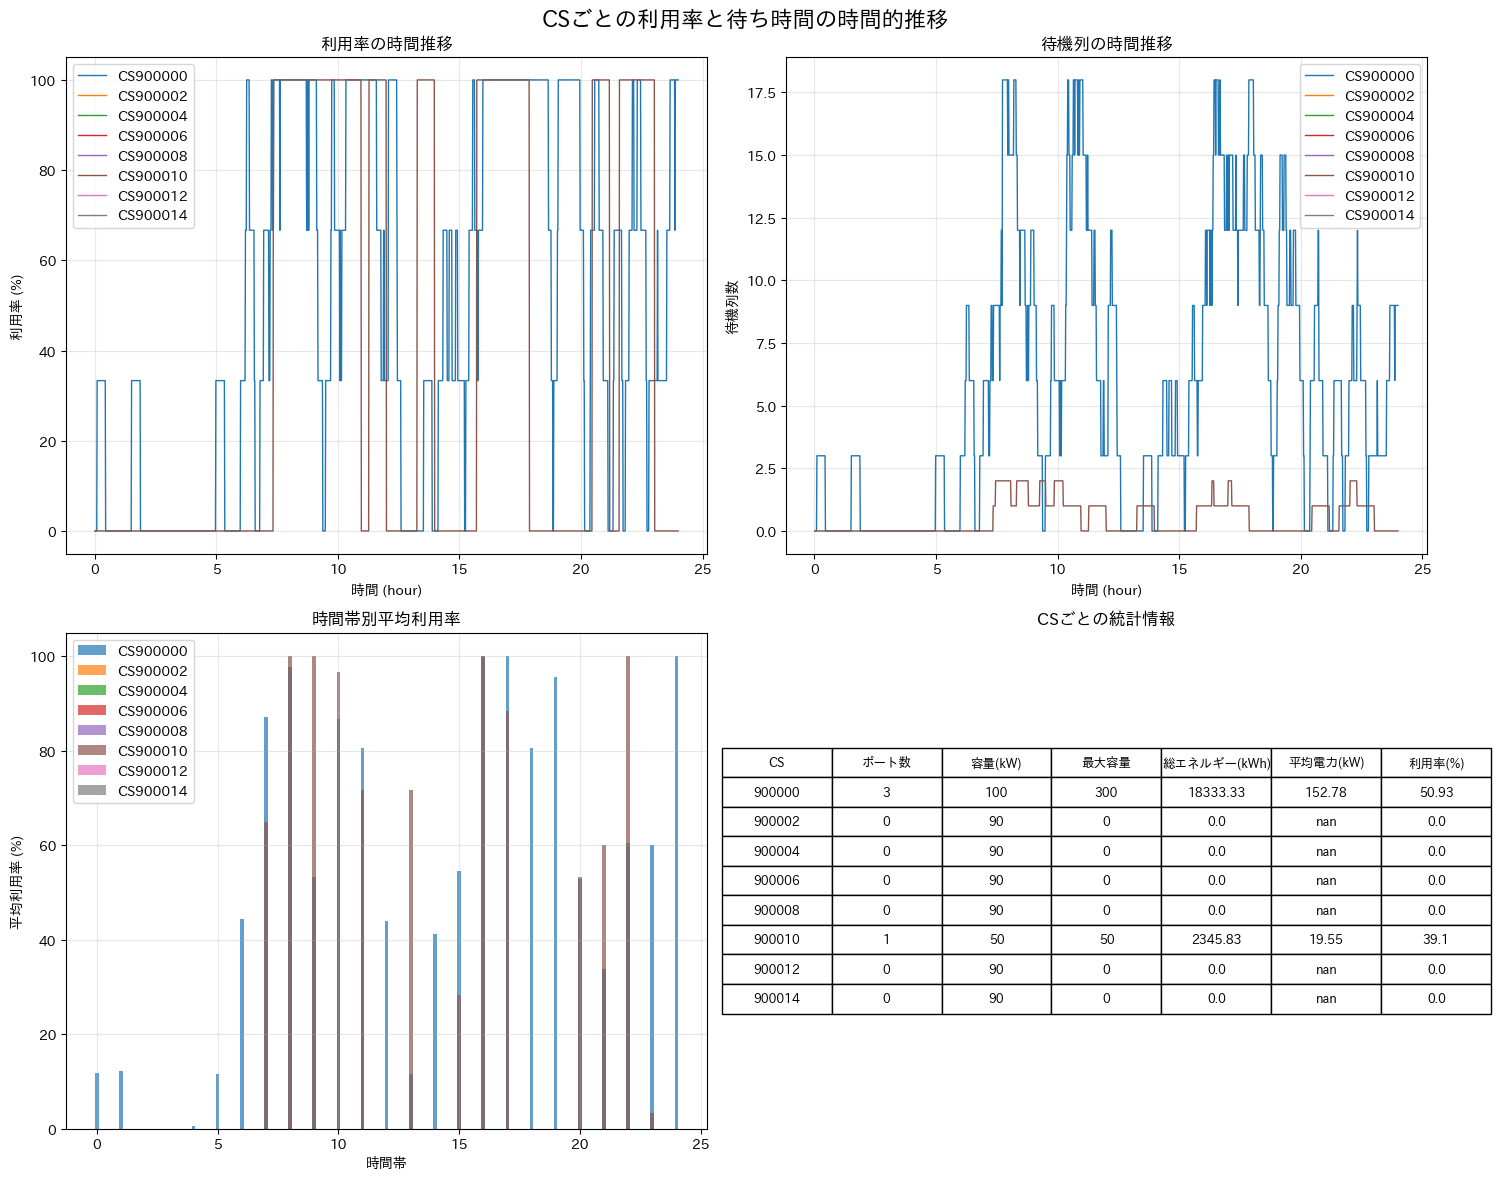

=== 待ち時間の詳細分析 ===
待ち時間が発生した充電回数: 57
全充電回数: 113
待ち時間発生率: 50.4%
平均待ち時間: 700.4秒 (11.7分)
最大待ち時間: 2269.6秒 (37.8分)


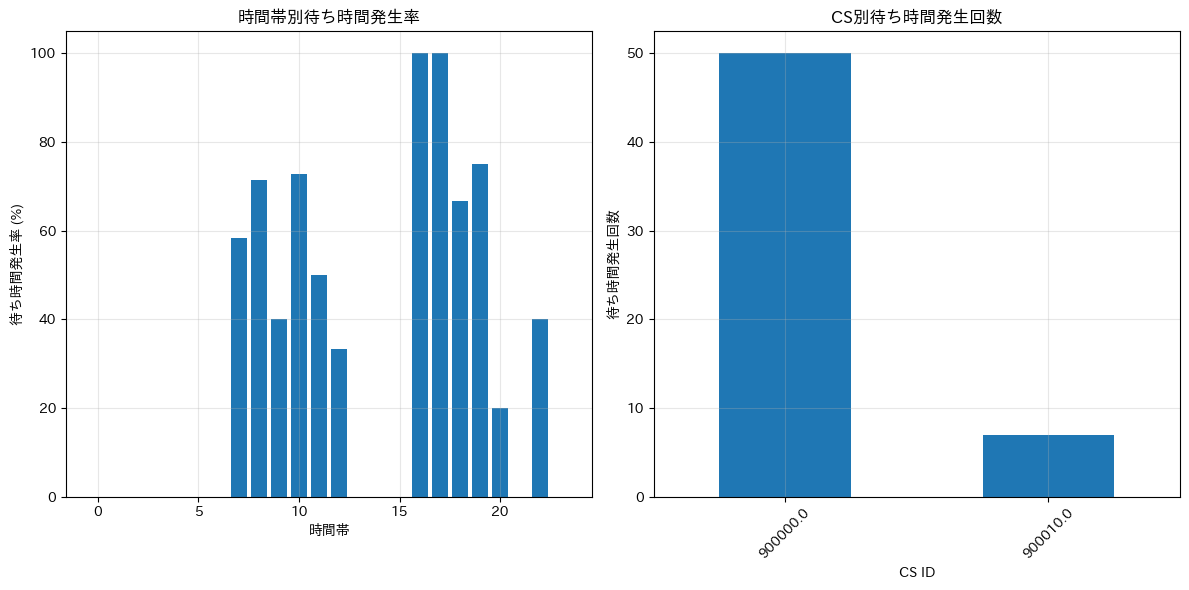


=== CSごとの詳細統計 ===
    CS  ポート数  容量(kW)  最大容量  総エネルギー(kWh)   平均電力(kW)    利用率(%)
900000     3     100   300 18333.333333 152.777778 50.925926
900002     0      90     0     0.000000        NaN  0.000000
900004     0      90     0     0.000000        NaN  0.000000
900006     0      90     0     0.000000        NaN  0.000000
900008     0      90     0     0.000000        NaN  0.000000
900010     1      50    50  2345.833333  19.548611 39.097222
900012     0      90     0     0.000000        NaN  0.000000
900014     0      90     0     0.000000        NaN  0.000000


In [ ]:
import seaborn as sns
from datetime import datetime, timedelta

# CSごとの利用率と待ち時間の時間的推移分析
import matplotlib.pyplot as plt

# データの前処理
# 時間軸を時間単位に変換（ElapsedTimeは秒）
timeseries_kw['hour'] = timeseries_kw.index / 3600
timeseries_waiting_line['hour'] = timeseries_waiting_line.index / 3600

# 設置されているCSのみを抽出
installed_cs = [col for col in timeseries_kw.columns if col in [str(csid) for csid in actual_csids]]

# 1. CSごとの利用率の時間的推移
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('CSごとの利用率と待ち時間の時間的推移', fontsize=16)

# 利用率の計算（最大容量に対する割合）
cs_utilization = {}
for cs in installed_cs:
    cs_idx = cs_config['csids'].index(int(cs))
    max_capacity = cs_config['ports'][cs_idx] * cs_config['cap_kw'][cs_idx]
    cs_utilization[cs] = timeseries_kw[cs] / max_capacity * 100

# 1-1. 利用率の時間推移
ax1 = axes[0, 0]
for cs in installed_cs:
    ax1.plot(timeseries_kw['hour'], cs_utilization[cs], label=f'CS{cs}', linewidth=1)
ax1.set_xlabel('時間 (hour)')
ax1.set_ylabel('利用率 (%)')
ax1.set_title('利用率の時間推移')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 1-2. 待機列の時間推移
ax2 = axes[0, 1]
for cs in installed_cs:
    ax2.plot(timeseries_waiting_line['hour'], timeseries_waiting_line[cs], 
             label=f'CS{cs}', linewidth=1)
ax2.set_xlabel('時間 (hour)')
ax2.set_ylabel('待機列数')
ax2.set_title('待機列の時間推移')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 2. 時間帯別の利用状況分析
# 時間帯別の平均利用率とピーク利用率
hourly_stats = {}
for cs in installed_cs:
    cs_data = timeseries_kw[cs].groupby(timeseries_kw.index // 3600).agg(['mean', 'max'])
    hourly_stats[cs] = cs_data

# 2-1. 時間帯別平均利用率
ax3 = axes[1, 0]
hours = range(24)
for cs in installed_cs:
    cs_idx = cs_config['csids'].index(int(cs))
    max_capacity = cs_config['ports'][cs_idx] * cs_config['cap_kw'][cs_idx]
    avg_utilization = hourly_stats[cs]['mean'] / max_capacity * 100
    ax3.bar(np.arange(len(avg_utilization)) + 0.1 * int(cs[-1]), avg_utilization, 
            width=0.15, label=f'CS{cs}', alpha=0.7)
ax3.set_xlabel('時間帯')
ax3.set_ylabel('平均利用率 (%)')
ax3.set_title('時間帯別平均利用率')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 2-2. CSごとの統計情報
ax4 = axes[1, 1]
cs_stats = []
for cs in installed_cs:
    cs_idx = cs_config['csids'].index(int(cs))
    ports = cs_config['ports'][cs_idx]
    capacity = cs_config['cap_kw'][cs_idx]
    max_capacity = ports * capacity
    
    total_energy = timeseries_kw[cs].sum()
    avg_power = timeseries_kw[cs].mean()
    peak_power = timeseries_kw[cs].max()
    if max_capacity == 0:
        utilization_rate = 0
    else:
        utilization_rate = (avg_power / max_capacity) * 100 
    
    cs_stats.append({
        'CS': cs,
        'ポート数': ports,
        '容量(kW)': capacity,
        '最大容量': max_capacity,
        '総エネルギー(kWh)': total_energy/12,  # 5分間隔なので12で割る
        '平均電力(kW)': avg_power,
        '利用率(%)': utilization_rate
    })

# 統計テーブルの表示
cs_stats_df = pd.DataFrame(cs_stats)
ax4.axis('tight')
ax4.axis('off')
table = ax4.table(cellText=cs_stats_df.round(2).values,
                  colLabels=cs_stats_df.columns,
                  cellLoc='center',
                  loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
ax4.set_title('CSごとの統計情報')

plt.tight_layout()
plt.show()

# 3. 待ち時間の詳細分析
print("=== 待ち時間の詳細分析 ===")
print(f"待ち時間が発生した充電回数: {len(non_zero_wait)}")
print(f"全充電回数: {len(charging_trip)}")
print(f"待ち時間発生率: {len(non_zero_wait)/len(charging_trip)*100:.1f}%")
print(f"平均待ち時間: {np.mean(non_zero_waiting_times):.1f}秒 ({np.mean(non_zero_waiting_times)/60:.1f}分)")
print(f"最大待ち時間: {np.max(non_zero_waiting_times):.1f}秒 ({np.max(non_zero_waiting_times)/60:.1f}分)")

# 4. 時間帯別の待ち時間分析
charging_trip['hour'] = (charging_trip['WaitingEntryTime'] // 3600).astype(int)
hourly_waiting = charging_trip.groupby('hour').agg({
    'EVID': 'count',
    'startChargingTime': lambda x: ((x - charging_trip.loc[x.index, 'WaitingEntryTime']) > 0).sum()
}).rename(columns={'EVID': 'total_charging', 'startChargingTime': 'waiting_count'})

hourly_waiting['waiting_rate'] = hourly_waiting['waiting_count'] / hourly_waiting['total_charging'] * 100

# 時間帯別待ち時間発生率のプロット
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(hourly_waiting.index, hourly_waiting['waiting_rate'])
plt.xlabel('時間帯')
plt.ylabel('待ち時間発生率 (%)')
plt.title('時間帯別待ち時間発生率')
plt.grid(True, alpha=0.3)

# CSごとの待ち時間発生箇所
plt.subplot(1, 2, 2)
waiting_cs.plot(kind='bar')
plt.xlabel('CS ID')
plt.ylabel('待ち時間発生回数')
plt.title('CS別待ち時間発生回数')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== CSごとの詳細統計 ===")
print(cs_stats_df.to_string(index=False))


### 故障を考慮した際のコストと95パーセンタイル待ち時間（ワーストケース）のパレートフロントを可視化する。

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import japanize_matplotlib
SAVE_DIR = '20250804_1716'


def cs_placement_objective_failure_only(trial) -> tuple:
    """故障時のみを考慮した多目的最適化の目的関数"""
    # 1. OptunaによるCS配置の提案
    cs_config = _set_cs_placement(trial)
    
    # 2. CS配置の妥当性チェック
    if not _check_cs_placement(cs_config):
        print("CS配置が不適切です。最低2箇所の充電ステーションを設置してください。")
        return float('inf'), float('inf')
    
    # 3. 目的1: CS建設・運用コスト（故障シナリオでの平均コスト）
    worst_failure_cost = calculate_worst_case_failure_cost(cs_config, trial)
    
    # 4. 目的2: 故障時の最悪ケース95%待ち時間
    worst_wait_time = calculate_worst_case_wait_time(cs_config, trial)
    
    return worst_failure_cost, worst_wait_time

def calculate_worst_case_failure_cost(cs_config: dict, trial) -> float:
    """全故障シナリオで最悪（最大）の運用コストを計算"""
    # 設置されているCSのインデックスを取得
    installed_cs_indices = [i for i, ports in enumerate(cs_config['ports']) if ports > 0]
    
    if len(installed_cs_indices) == 0:
        return float('inf')
    
    worst_cost = 0.0
    all_costs = []
    
    for failure_cs_idx in installed_cs_indices:
        # 各CSが故障するシナリオを作成
        _create_failure_info(cs_config=cs_config, failure_cs_index=failure_cs_idx)
        
        # シミュレーション実行
        run_parallel_emates_simulations(base_config=cs_config, parallel_count=1)
        
        # データの保存
        results_filename = f"trial_{trial.number}_failure_cs_{failure_cs_idx}.pkl"
        results_filepath = os.path.join(SAVE_DIR, results_filename)
        save_data_to_pickle(worker_id=1, filename=results_filepath)
        
        # この故障シナリオでのコストを計算
        failure_cost, _ = total_costs_yearly(result_file=results_filepath)
        all_costs.append(failure_cost)
        
        # 最悪ケース（最大コスト）を更新
        if failure_cost > worst_cost:
            worst_cost = failure_cost
        
        print(f"故障CS{failure_cs_idx}でのコスト: {failure_cost:.2f}万円")
    
    print(f"故障シナリオ別コスト: {all_costs}")
    print(f"最悪ケースコスト: {worst_cost:.2f}万円")
    
    return worst_cost

def calculate_worst_case_wait_time(cs_config: dict, trial) -> float:
    """全故障シナリオの中で最悪の95パーセンタイル待ち時間を計算"""
    # 設置されているCSのインデックスを取得
    installed_cs_indices = [i for i, ports in enumerate(cs_config['ports']) if ports > 0]
    
    if len(installed_cs_indices) == 0:
        return float('inf')
    
    worst_wait_time = 0.0
    all_wait_times = []
    
    for failure_cs_idx in installed_cs_indices:
        # 故障シナリオファイルは既に calculate_average_failure_cost で作成済み
        results_filename = f"trial_{trial.number}_failure_cs_{failure_cs_idx}.pkl"
        results_filepath = os.path.join(SAVE_DIR, results_filename)
        
        # この故障シナリオでの95パーセンタイル待ち時間を計算
        wait_time_95p = calculate_95percentile_wait_time(results_filepath)
        all_wait_times.append(wait_time_95p)
        
        # 最悪ケースを更新
        if wait_time_95p > worst_wait_time:
            worst_wait_time = wait_time_95p
    
    print(f"故障シナリオ別95%待ち時間: {all_wait_times}")
    print(f"最悪ケース95%待ち時間: {worst_wait_time:.2f}秒")
    
    return worst_wait_time

def calculate_95percentile_wait_time(result_file: str) -> float:
    """95パーセンタイル待ち時間を計算"""
    with open(result_file, 'rb') as f:
        emates_result = pickle.load(f)
    
    vehicle_trip = emates_result['vehicle_trip']
    
    # 充電を行ったトリップのみを抽出
    charging_trip = vehicle_trip[vehicle_trip['startChargingTime'] != 0].copy()
    
    if len(charging_trip) == 0:
        return float('inf')  # 充電できなかった場合は無限大
    
    # 完了した充電のみを対象（EndTimeがNaNでない）
    completed_charging = charging_trip[~charging_trip['EndTime'].isna()].copy()
    
    if len(completed_charging) == 0:
        return float('inf')  # 完了した充電がない場合は無限大
    
    # 待ち時間を計算
    waiting_times = (completed_charging['startChargingTime'].values - 
                    completed_charging['WaitingEntryTime'].values)
    
    # 95パーセンタイル待ち時間を計算
    wait_time_95p = np.percentile(waiting_times, 95)
    
    return wait_time_95p

# 故障時専用の最適化実行関数
def run_optuna_failure_optimization(n_trials=50):
    """故障時のみを考慮した多目的最適化の実行"""
    # SQLiteデータベースを使用したStudy管理
    db_path = os.path.join(SAVE_DIR, 'optuna_failure_study.db')
    db_url = f"sqlite:///{db_path}"
    study_name = "cs_failure_optimization"
    
    try:
        study = optuna.load_study(
            study_name=study_name, 
            storage=db_url,
        )
        print(f"既存の故障時最適化Studyを読み込みました（トライアル数: {len(study.trials)}）")
        print(f"最適化方向: {study.directions}")
    except KeyError:
        # 新しい故障時専用Studyを作成
        study = optuna.create_study(
            directions=['minimize', 'minimize'],  # [故障時平均コスト, 最悪待ち時間]
            study_name=study_name, 
            storage=db_url
        )
        print("新しい故障時専用Studyを作成しました")
    
    # 最適化実行
    study.optimize(cs_placement_objective_failure_only, n_trials=n_trials)
    
    # パレートフロントの可視化
    visualize_failure_pareto_front(study)
    
    # 結果保存
    save_failure_optimization_results(study)
    
    return study

def visualize_failure_pareto_front(study):
    """故障時パレートフロントの可視化"""
    import matplotlib.pyplot as plt
    
    # 完了したトライアルのみを取得
    completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    
    if len(completed_trials) == 0:
        print("完了したトライアルがありません")
        return
    
    # 無限大値を除外
    finite_trials = [t for t in completed_trials if not any(v == float('inf') for v in t.values)]
    
    if len(finite_trials) == 0:
        print("有効な解がありません")
        return
    
    # 目的関数値を取得
    costs = [t.values[0] for t in finite_trials]
    wait_times = [t.values[1] for t in finite_trials]
    
    # パレート最適解を取得
    pareto_trials = study.best_trials
    pareto_costs = [t.values[0] for t in pareto_trials if not any(v == float('inf') for v in t.values)]
    pareto_wait_times = [t.values[1] for t in pareto_trials if not any(v == float('inf') for v in t.values)]
    
    # プロット
    plt.figure(figsize=(12, 8))
    plt.scatter(costs, wait_times, alpha=0.6, label='全解', color='lightblue')
    if pareto_costs and pareto_wait_times:
        plt.scatter(pareto_costs, pareto_wait_times, color='red', s=100, label='パレート最適解', zorder=5)
        
        # パレート最適解に番号を付ける
        for i, (cost, wait) in enumerate(zip(pareto_costs, pareto_wait_times)):
            plt.annotate(f'P{i}', (cost, wait), xytext=(5, 5), 
                        textcoords='offset points', fontsize=8)
    
    plt.xlabel('故障時平均コスト (万円)')
    plt.ylabel('最悪ケース95%待ち時間 (秒)')
    plt.title('故障時のコスト vs 待ち時間パレートフロント')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # パレート最適解の詳細を表示
    print("\n=== 故障時パレート最適解 ===")
    valid_pareto_trials = [t for t in study.best_trials if not any(v == float('inf') for v in t.values)]
    for i, trial in enumerate(valid_pareto_trials):
        print(f"解P{i}: 故障時平均コスト={trial.values[0]:.2f}万円, "
              f"最悪待ち時間={trial.values[1]:.2f}秒")
        print(f"  パラメータ: {trial.params}")

def save_failure_optimization_results(study):
    """故障時最適化結果の保存"""
    results_dir = os.path.join(SAVE_DIR, 'failure_optimization_results')
    os.makedirs(results_dir, exist_ok=True)
    
    # パレート最適解の保存（無限大値を除外）
    pareto_results = []
    valid_pareto_trials = [t for t in study.best_trials if not any(v == float('inf') for v in t.values)]
    
    for i, trial in enumerate(valid_pareto_trials):
        pareto_results.append({
            'solution_id': f'P{i}',
            'failure_avg_cost': trial.values[0],
            'worst_wait_time': trial.values[1],
            'params': trial.params,
            'trial_number': trial.number
        })
    
    with open(os.path.join(results_dir, 'failure_pareto_solutions.json'), 'w', encoding='utf-8') as f:
        json.dump(pareto_results, f, indent=2, ensure_ascii=False)
    
    # 全トライアルの結果も保存
    all_results = []
    for trial in study.trials:
        if trial.state == optuna.trial.TrialState.COMPLETE and not any(v == float('inf') for v in trial.values):
            all_results.append({
                'trial_number': trial.number,
                'failure_avg_cost': trial.values[0],
                'worst_wait_time': trial.values[1],
                'params': trial.params
            })
    
    with open(os.path.join(results_dir, 'all_failure_results.json'), 'w', encoding='utf-8') as f:
        json.dump(all_results, f, indent=2, ensure_ascii=False)
    
    print(f"故障時パレート最適解を {results_dir}/failure_pareto_solutions.json に保存しました")
    print(f"全結果を {results_dir}/all_failure_results.json に保存しました")

# 実行例
# 故障時のみの最適化を実行
study_failure = run_optuna_failure_optimization(n_trials=150)


既存の故障時最適化Studyを読み込みました（トライアル数: 3）
最適化方向: [<StudyDirection.MINIMIZE: 1>, <StudyDirection.MINIMIZE: 1>]


シミュレーション実行中: 100%|██████████| 1/1 [04:15<00:00, 255.86s/it]


故障CS0でのコスト: 7502.60万円


シミュレーション実行中: 100%|██████████| 1/1 [04:19<00:00, 259.44s/it]


故障CS1でのコスト: 7503.75万円


...

シミュレーション実行中: 100%|██████████| 1/1 [04:27<00:00, 267.21s/it]


故障CS1でのコスト: 8787.28万円


シミュレーション実行中: 100%|██████████| 1/1 [04:24<00:00, 264.72s/it]


故障CS2でのコスト: 8859.09万円


シミュレーション実行中:   0%|          | 0/1 [00:00<?, ?it/s]

### 並列実行